This notebook will show you how you can do some basic data work in python:
1) loading data
2) maniputating that data
3) plotting the data
4) calculating stats
5) running regression
6) plotting the results of an analysis




Step 1: Reading the data from an Excel file

In [ ]:
import pandas as pd
data = pd.read_excel('/content/python_data.xlsx', engine = 'openpyxl')
data.head()

,Date,AAPL,IBM,SPY,T30
0,2000-01-31,0.0091,0.0406,-0.0494,0.004343
1,2000-02-29,0.1048,-0.0837,-0.0157,0.004295
2,2000-03-31,0.1848,0.1484,0.0969,0.004377
3,2000-04-28,-0.0865,-0.0551,-0.0351,0.004595
4,2000-05-31,-0.3229,-0.0359,-0.0157,0.004782


Step 2: Manipulating data
For example, we want to calculate excess returns ans store them in our data

In [ ]:
eaapl = data['AAPL'] - data['T30']
data['eAAPL'] = eaapl

eibm = data['IBM'] - data['T30']
data['eIBM'] = eibm

espy = data['SPY'] - data['T30']
data['eSPY'] = espy

data.head()

,Date,AAPL,IBM,SPY,T30,eAAPL,eIBM,eSPY
0,2000-01-31,0.0091,0.0406,-0.0494,0.004343,0.004757,0.036257,-0.053743
1,2000-02-29,0.1048,-0.0837,-0.0157,0.004295,0.100505,-0.087995,-0.019995
2,2000-03-31,0.1848,0.1484,0.0969,0.004377,0.180423,0.144023,0.092523
3,2000-04-28,-0.0865,-0.0551,-0.0351,0.004595,-0.091095,-0.059695,-0.039695
4,2000-05-31,-0.3229,-0.0359,-0.0157,0.004782,-0.327682,-0.040682,-0.020482


Step 3: Plot data
For example, we can plot the histogram of the excess returns eAAPL, eIBM, eSPY

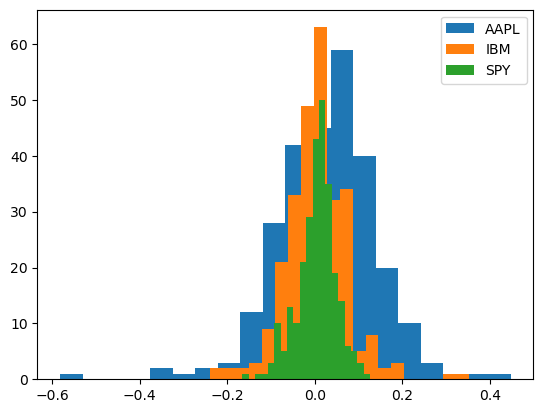

In [ ]:
from matplotlib import pyplot as plt
plt.hist(data['eAAPL'], bins = 20, label = 'AAPL')
plt.hist(data['eIBM'], bins = 20, label = 'IBM')
plt.hist(data['eSPY'], bins = 20, label = 'SPY')
plt.legend(prop={'size':10})

We can also plot one variable against another
For example, we can plot eAAPL against eSPY

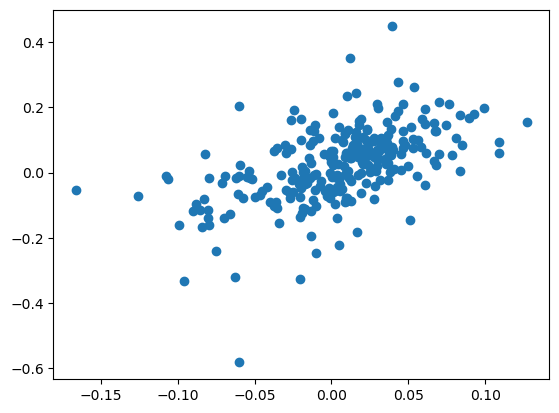

In [ ]:
plt.scatter(data['eSPY'],data['eAAPL'])

Step 4: Calculating stats on data
For example, calculating the mean and stdev for eAAPL

In [ ]:
eAAPL_mean = round(data['eAAPL'].mean(),4)
eAAPL_std = round(data['eAAPL'].std(),4)

Step 5: Run a regression
For example we want to run a regression of eAAPL on eSPY
The package that handles this type of ananlysis is numpy, so we need to load it first

In [ ]:
import numpy as np
regAAPL = np.polyfit(x=data['eSPY'], y=data['eAAPL'], deg=1)
regAAPL

array([1.39203964, 0.01829872])

Step 6: Plot the linear model obtained from running the regression

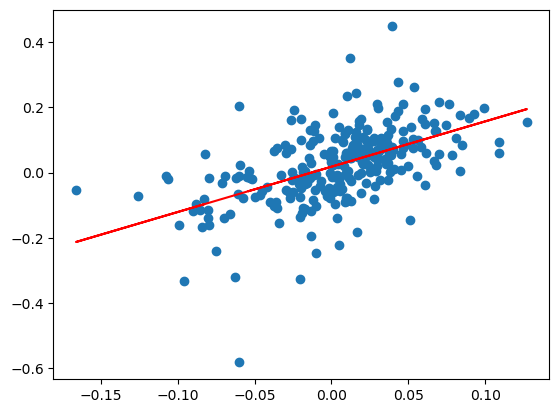

In [ ]:
trendAAPL = np.polyval(regAAPL,data['eSPY'])
plt.scatter(data['eSPY'],data['eAAPL'])
plt.plot(data['eSPY'],trendAAPL,'r')